# Process Annotated Data
Translate Label Studio JSON files to a format for ML

In [63]:
import json
import ast
from datetime import datetime
from collections import defaultdict
from typing import Any, Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import spacy
import pandas as pd

from utils.utils import analyze_category_distribution_from_dict, plot_cooccurrence_heatmap

In [64]:
ANNOTATED_DATA_JSON_PATH = "../data/input/annotated-gold-standard.json"
TAXONOMY_PATH = "../data/output/taxonomy_autogen_v2.csv"

OUTPUT_PATH = "../data/output/gold_standard.json"
TAXONOMY_V3_PATH = "../data/output/taxonomy_autogen_v3.csv"

RANDOM_STATE = 42

## Import from JSON file

In [65]:
with open(ANNOTATED_DATA_JSON_PATH, 'r', encoding='utf-8') as f:
    data = json.load(f)

len(data)

2000

In [66]:
taxonomy = pd.read_csv(TAXONOMY_PATH)
taxonomy.head(5)

,high_level_category,category_description,values_hint,cat_label,regex
0,Care,Care experienced,"['Care leaver', 'Care experienced (under 25)']",care_care_experienced,\bcare experienced\b|\bcare leaver\b|\baged ou...
1,Care,Care setting,"['Fostered', 'Social care']",care_care_setting,\bfostered\b|\bfoster care\b|\bfoster placemen...
2,Care,Has caring responsibility,"['Formal', 'Informal']",care_has_caring_responsibility,\bformal carer\b|\bregistered carer\b|\bcarer....
3,Care,Social care involvement,"['Adult Social Care', ""Children's Social Care""]",care_social_care_involvement,\bsocial care\b|\bcare package\b|\bcare plan\b...
4,Cautions,ASBO or injunction obtained,"['ASBO', 'Injunction']",cautions_asbo_or_injunction_obtained,\bASBO\b|\binjunction\b|\bcivil injunction\b|\...


## Format

Strip out Label Studio Metadata, make sure spans are aligned with tokens (spacy).

In [67]:
ENTITY_LABELS = {"Person_Name", "Person_Role", "Person_Pronoun"}
CAT_LABELS = set(taxonomy.cat_label.values.tolist())
nlp = spacy.blank("en")

In [68]:

def extract_annotations(task: Dict[str, Any]) -> Dict[str, Any] | None:
    # 1. Get note content and ID
    id = task["data"]["id"]
    text = task["data"]["note_content"]
    doc = nlp.make_doc(text)

    # 2. Get annotations from array - most recent
    task_annotations = task["annotations"]
    
    if len(task_annotations) == 0:
        print(f"Note with id {id} has no annotations.")
        return None
    else:
        # Fix accidental duplicated annotations - choose earliest one
        annotation = min(task_annotations, key=lambda x: datetime.strptime(x["created_at"], "%Y-%m-%dT%H:%M:%S.%fZ"))
    
    annotation_date = datetime.strptime(annotation["created_at"], "%Y-%m-%dT%H:%M:%S.%fZ")
    labels = annotation["result"]

    # 3. Handle annotations
    needs = []
    persons = []
    relations = []
    seen_ids = set()

    # 3.1. Handle text labels first
    for l in labels:
        if l["type"] != "labels":
            continue

        entity_id = l["id"]
        label = l["value"]["labels"][0]
        original_start = l["value"]["start"]
        original_end = l["value"]["end"]

        # Check span is correct - expand to capture dangling letters (e.g. 's' in tenants)
        span = doc.char_span(original_start, original_end, alignment_mode="expand")
        if span is None:
            print(f"Skipping null span. Annotation Entity ID: '{entity_id}', Note ID: '{id}'")
            continue

        # Clean up accidental whitespace & calculate the new character indices
        clean_text = span.text.strip()
        new_start = span.start_char + (len(span.text) - len(span.text.lstrip()))
        new_end = new_start + len(clean_text)

        # Save to seen_ids and relevant list
        if entity_id not in seen_ids:
            seen_ids.add(entity_id)
        
        item = {"id": entity_id, "text": clean_text, "start": new_start, "end": new_end, "label": label}

        # Needs
        if l["from_name"] == "need_labels" and label in CAT_LABELS:
            needs.append(item)
        # Persons
        elif l["from_name"] == "entity_labels" and label in ENTITY_LABELS:
            persons.append(item)
        else:
            print(f"Skipping unknown label: type: '{l['from_name']}', label: '{label}' in note '{id}'")

    # 3.2. Handle relations second (make sure all IDs exist)
    for l in labels:
        if l["type"] != "relation":
            continue

        from_id = l["from_id"]
        to_id = l["to_id"]

        if from_id in seen_ids and to_id in seen_ids:
            relations.append({"from": from_id, "to": to_id})
        else:
            print(f"Skipping relation between unknown id(s): from: '{from_id}', to: '{to_id}' in note '{id}'")

    return {
        "id": id,
        "label_studio_id": task['id'],
        "annotation_date": annotation_date,
        "text": text,
        "needs": needs,
        "persons": persons,
        "relations": relations,
    }

In [69]:
records = [extract_annotations(task) for task in data]

In [70]:
records[1]

{'id': '685524bb-94d4-4f08-8669-0e78df744c0c',
 'label_studio_id': 28101,
 'annotation_date': datetime.datetime(2026, 5, 19, 15, 18, 59, 455700),
 'text': '[Category: tenureManagement] Welfare check and tenancy audit completed I visited the tenant in his property following his request for me to come over and assess the toilet in his property. I used the opportunity to complete a tenancy audit and I observed that he is a hoarder with so many items in nearly all the rooms. The toilet seat has broken and the toilet is as dark as charcoal.',
 'needs': [{'id': '3aefb716',
   'text': 'hoarder',
   'start': 268,
   'end': 275,
   'label': 'housing_conditions_hoarding'},
  {'id': '99751da7',
   'text': 'so many items in nearly all the rooms',
   'start': 281,
   'end': 318,
   'label': 'housing_conditions_hoarding'},
  {'id': '354b3b37',
   'text': 'toilet seat has broken',
   'start': 324,
   'end': 346,
   'label': 'property_level_disrepair_damp_mould'},
  {'id': 'c8515bee',
   'text': 'toil

## Find Duplicates (on note text), ensure annotations are identical

In [71]:
# Group records by exact text match
grouped = defaultdict(list)
for record in records:
    grouped[record["text"]].append(record)
len(grouped)

1908

In [72]:
for note_content, duplicates in grouped.items():
    if len(duplicates) == 1:
        continue
    
    # If duplicated, choose latest annotation
    duplicates.sort(key=lambda x: x['annotation_date'], reverse=True)
    newest = duplicates[0]

    for record in duplicates:
        if (
            record["needs"] != newest["needs"]
            or record["persons"] != newest["persons"]
            or record["relations"] != newest["relations"]
        ):
            print(f"Replacing annotations for note '{record['id']}' with note '{newest['id']}'.")
            record['needs'] = newest['needs']
            record['persons'] = newest['persons']
            record['relations'] = newest['relations']

Replacing annotations for note 'b7b3fb41-80b7-4d97-b8f4-0e0a7156ab79' with note 'b30cc085-4908-4612-9050-f49b6d7d2f04'.
Replacing annotations for note '44683a11-6a65-4a2f-ae9e-8296fc794d5b' with note '749ba836-2c77-4723-b9f5-574eaa2c70ab'.
Replacing annotations for note '169c4fff-f124-416b-ab22-f0caaa2f527a' with note 'd5a9d2e5-4139-42d2-8bea-972e04cafe27'.
Replacing annotations for note '5fd5e463-dc99-4704-8c6d-f4f6c3a73bbf' with note '7ea1211f-f951-41a5-a48b-7c73595796ba'.
Replacing annotations for note '7b13a8be-d9c1-4622-9b7b-0ae348250941' with note '5c413ffb-56b1-4493-83ee-5988138022a2'.
Replacing annotations for note '6b3f7867-4469-4025-bd93-8cb24a36b236' with note '5e55ad28-e2f6-442a-85fa-d9a31ccc89b2'.
Replacing annotations for note '4cbbe8aa-2582-4b25-81eb-74f950c254d1' with note '9267a6a1-a3ce-4579-a35a-735398856cb9'.
Replacing annotations for note 'daab8f3a-046e-40b3-9f0f-6199a68ea072' with note 'c5c97af9-262c-4a88-824c-f478b7931204'.
Replacing annotations for note '284d4a30

## Check Total Annotation Time (Hours)

In [73]:
# Count lead time
lead_times = [x['annotations'][0]['lead_time'] for x in data if len(x["annotations"]) > 0]
sum([t for t in lead_times if t is not None])/(60*60)

24.54153388888888

## Analyse distribution

,label,frequency,IRLbl
0,health_medical_condition,314,1.000000
1,property_level_disrepair_damp_mould,289,1.086505
2,safety_risk_antisocial_behaviour,272,1.154412
3,care_social_care_involvement,221,1.420814
4,health_mental_health,172,1.825581
5,health_care_setting,166,1.891566
6,mobility_mobility_physical,158,1.987342
7,life_events_temporary,147,2.136054
8,disability_requires_adapted_property,137,2.291971
9,life_events_life_events,126,2.492063


,Metric,Value
0,MeanIR,6.45
1,MaxIR,52.33
2,CVIR,1.32


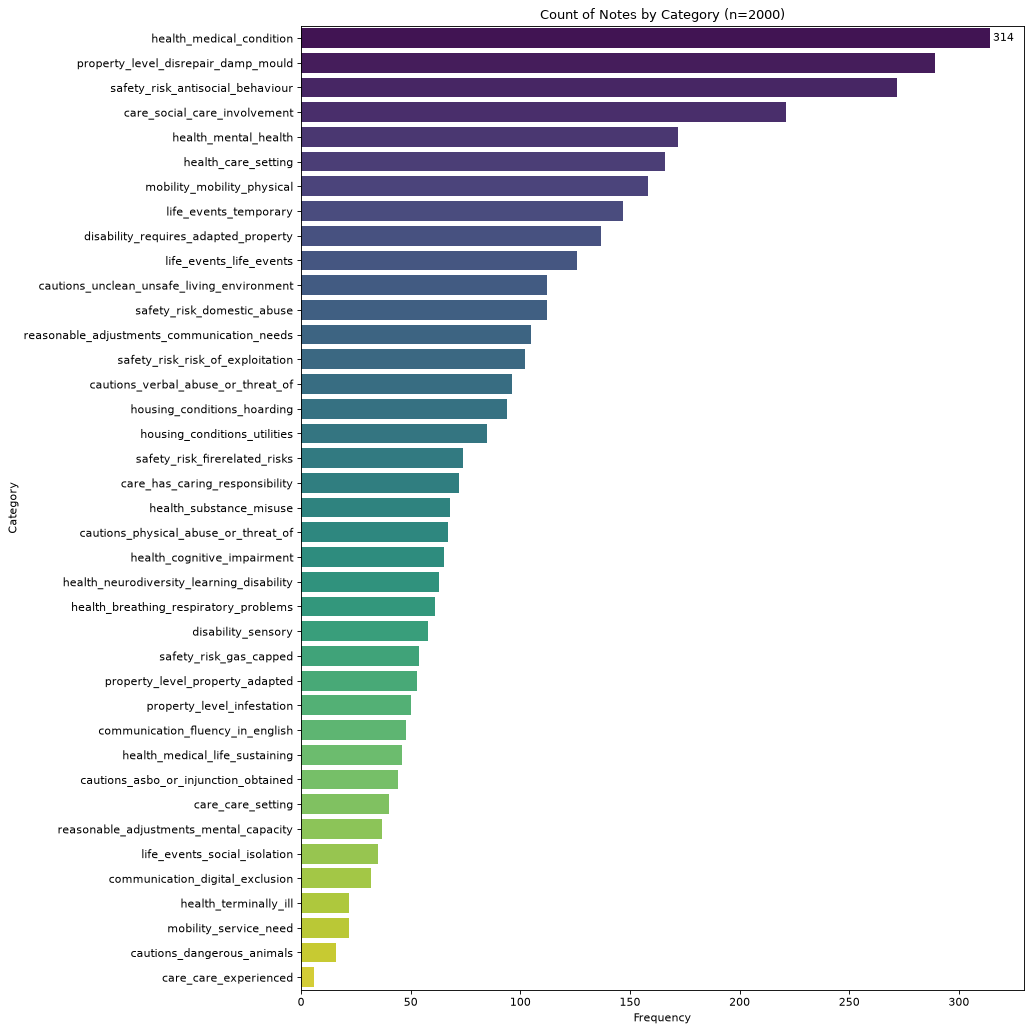

In [74]:
(irlbl_df, summary, ax) = analyze_category_distribution_from_dict(records, taxonomy, log_scale=False)

display(irlbl_df.style.background_gradient(cmap='Reds', subset=['IRLbl']))
display(summary)
plt.show()

## Combine Low Prevalence Categories

In [75]:
MERGE_MAP = {
    "care_care_experienced": "life_events_life_events",
    "cautions_dangerous_animals": "safety_risk_antisocial_behaviour",
    "mobility_service_need": "mobility_mobility_physical",
    "health_medical_life_sustaining": "health_terminally_ill",
    "reasonable_adjustments_mental_capacity": "reasonable_adjustments_communication_needs",
    "life_events_social_isolation": "life_events_life_events",
}


In [76]:
taxonomy_v3['values_hint']
taxonomy.dtypes

high_level_category     str
category_description    str
values_hint             str
cat_label               str
regex                   str
dtype: object

In [77]:
taxonomy_v3 = taxonomy.copy()
taxonomy_v3['values_hint'] = taxonomy_v3['values_hint'].apply(ast.literal_eval)

# Merge regexes & values_hint to the new label
for old_label, new_label in MERGE_MAP.items():
    old_row = taxonomy_v3[taxonomy_v3['cat_label'] == old_label].iloc[0]
    new_idx = taxonomy_v3[taxonomy_v3['cat_label'] == new_label].index[0]

    old_regex = old_row['regex'].strip()
    new_regex = taxonomy_v3.at[new_idx, 'regex'].strip()
    taxonomy_v3.at[new_idx, 'regex'] = f"(?:{old_regex})|(?:{new_regex})"
    print(f"Merged regex: '{old_label}' + '{new_label}' -> combined pattern on '{new_label}' row")

    old_values = old_row['values_hint']
    new_values = taxonomy_v3.at[new_idx, 'values_hint']
    taxonomy_v3.at[new_idx, 'values_hint'] = new_values + old_values
    print(f"Merged value_hint: '{old_values}' + '{new_values}' -> combined on '{new_label}' row")


# Drop old labels & save
labels_to_drop = set(MERGE_MAP.keys())
taxonomy_v3 = taxonomy_v3[~taxonomy_v3['cat_label'].isin(labels_to_drop)].reset_index(drop=True)
taxonomy_v3.to_csv(TAXONOMY_V3_PATH, index=False)

Merged regex: 'care_care_experienced' + 'life_events_life_events' -> combined pattern on 'life_events_life_events' row
Merged value_hint: '['Care leaver', 'Care experienced (under 25)']' + '['Ex service personnel', 'In prison', 'Left prison']' -> combined on 'life_events_life_events' row
Merged regex: 'cautions_dangerous_animals' + 'safety_risk_antisocial_behaviour' -> combined pattern on 'safety_risk_antisocial_behaviour' row
Merged value_hint: '['Dog', 'Reptile', 'Other']' + '['Perpetrator of harassment', 'Victim of harassment', 'Perpetrator of hate crime', 'Victim of hate crime']' -> combined on 'safety_risk_antisocial_behaviour' row
Merged regex: 'mobility_service_need' + 'mobility_mobility_physical' -> combined pattern on 'mobility_mobility_physical' row
Merged value_hint: '['Unable to answer door', 'Allow time to answer door', 'Prepayment Meter - can’t access', 'Personal Emergency Evaculation Plan (PEEP)']' + '['Frail', 'History of falls', 'Limited mobility: Zimmer frame', 'Limit

In [78]:
records_v2 = []

# Loop through and 
for record in records:
    new_record = record.copy()
    for ann in new_record.get("needs", []):
        old_label = ann['label']
        if old_label in labels_to_drop:
            new_label = MERGE_MAP.get(old_label)
            ann['label'] = new_label
            print(f"Replaced label '{old_label}' with '{new_label}' in note {new_record['id']}.")
    records_v2.append(new_record)

Replaced label 'life_events_social_isolation' with 'life_events_life_events' in note d02ee213-1785-1603-e09f-e518b5a8954d.
Replaced label 'life_events_social_isolation' with 'life_events_life_events' in note d02ee213-1785-1603-e09f-e518b5a8954d.
Replaced label 'care_care_experienced' with 'life_events_life_events' in note ea4dfca4-2217-d79a-1006-237e50da9a6e.
Replaced label 'care_care_experienced' with 'life_events_life_events' in note c3c542ef-c255-b431-78df-1a85e12fc2a5.
Replaced label 'life_events_social_isolation' with 'life_events_life_events' in note 78548da4-ee06-4dc0-907c-de6b18422a06.
Replaced label 'mobility_service_need' with 'mobility_mobility_physical' in note 7bb4875e-96e1-47e0-94bb-512317b945a5.
Replaced label 'reasonable_adjustments_mental_capacity' with 'reasonable_adjustments_communication_needs' in note 5c4a7f84-d8d5-f17a-8ebf-7fcb3df260ba.
Replaced label 'health_medical_life_sustaining' with 'health_terminally_ill' in note 6e59bfef-6511-085c-df46-968a4daf411a.
Repla

,label,frequency,IRLbl
0,health_medical_condition,314,1.000000
1,property_level_disrepair_damp_mould,289,1.086505
2,safety_risk_antisocial_behaviour,283,1.109541
3,care_social_care_involvement,221,1.420814
4,health_mental_health,172,1.825581
5,mobility_mobility_physical,172,1.825581
6,health_care_setting,166,1.891566
7,life_events_life_events,161,1.950311
8,life_events_temporary,147,2.136054
9,reasonable_adjustments_communication_needs,139,2.258993


,Metric,Value
0,MeanIR,3.94
1,MaxIR,9.81
2,CVIR,0.55


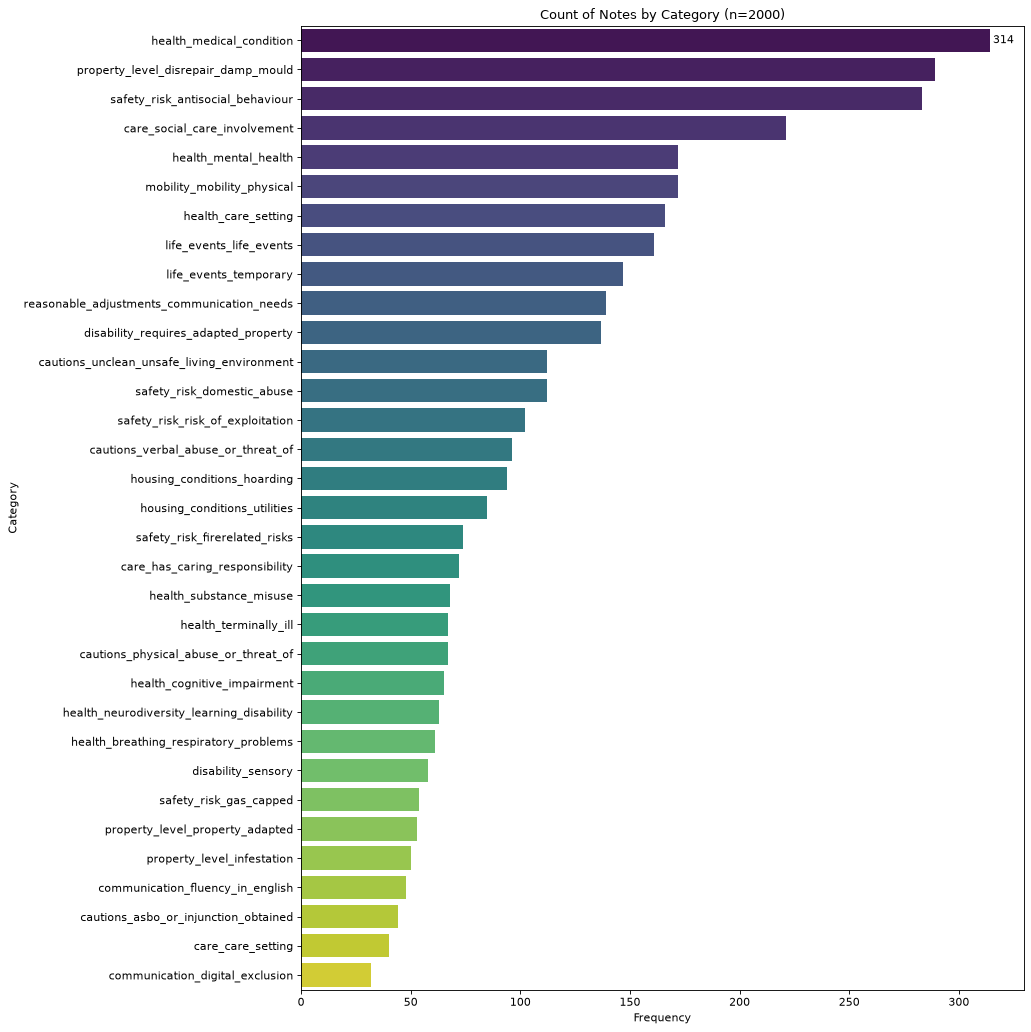

In [79]:
(irlbl_df, summary, ax) = analyze_category_distribution_from_dict(records_v2, taxonomy_v3, log_scale=False)

display(irlbl_df.style.background_gradient(cmap='Reds', subset=['IRLbl']))
display(summary)
plt.show()

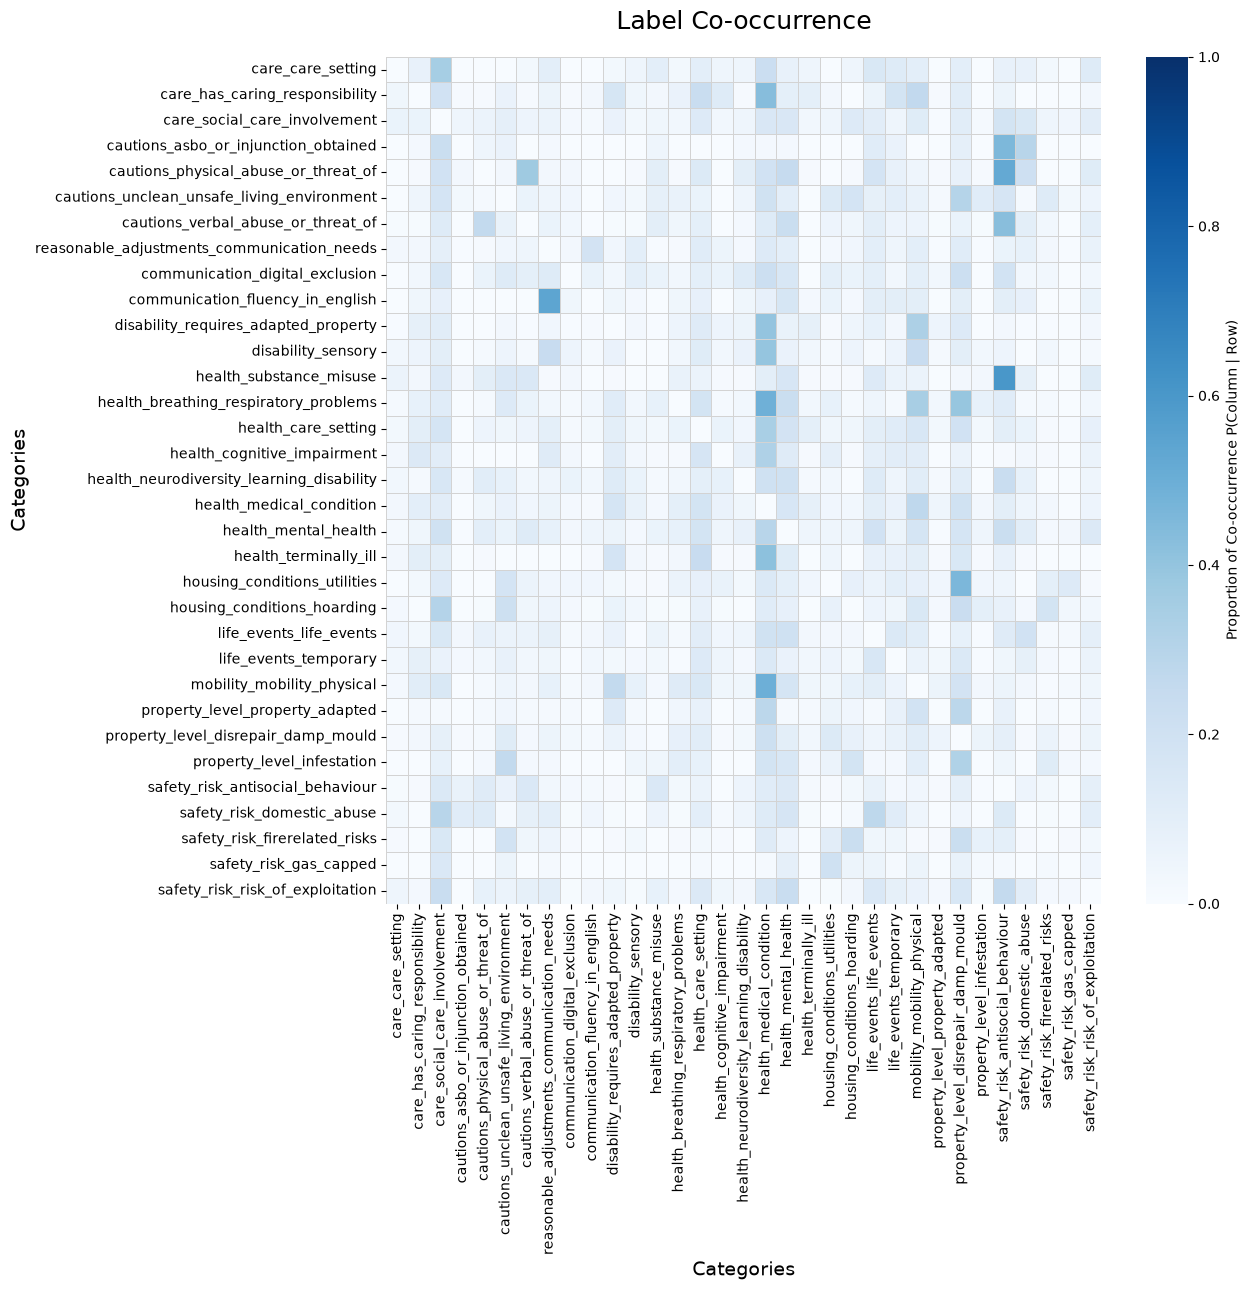

<Axes: title={'center': 'Label Co-occurrence'}, xlabel='Categories', ylabel='Categories'>

In [80]:
plot_cooccurrence_heatmap(records_v2, taxonomy_v3)

## Save as JSON

In [81]:
# Dump all
with open(OUTPUT_PATH, "w") as f:
    json.dump(records_v2, f, indent=2, default=str)
